# Monday Morning — Can Sarah Defend Her Number?
**⏱ This notebook takes approximately 15 minutes.**

---

## Scenario: The Number That Needs Defending

Sarah Chen works as a Customer Experience Analyst at NorthStar Retail.
Last Friday, she ran a pre-trained sentiment model on 10,000 customer reviews
and reported her findings to Priya, the CMO:

> *"60% of reviews are positive, 40% are negative."*

The room went quiet. Then Priya leaned forward:

> *"60%? Could it have been 50% if we just had a different week of reviews?"*

Sarah didn't have an answer. That question — **how sure are we?** — is what this
whole lesson is about.

This notebook shows you *exactly why* Priya's question is harder than it sounds.

**By the end of this notebook you'll see:**
- What Sarah's polarity score distribution actually looks like
- Why the mean and median tell different stories
- Why "60% positive" is a start, not an answer


In [1]:
# Setup — run this cell first
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")
np.random.seed(42)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)
print("✅ Libraries loaded — you're ready to go!")


✅ Libraries loaded — you're ready to go!


## Sarah's L01 Results — Recreating the Data

Below we recreate the polarity scores from Sarah's L01 model run.
In a real project these would be saved to a CSV file —
for this notebook we generate them synthetically with the same statistical
properties Sarah would have seen.

Each value is a **polarity score**: a number between −1 (very negative) and +1 (very positive)
that the sentiment model assigns to each review.


In [2]:
# Recreate Sarah's polarity score data (same seed as 02_distributions.ipynb)
# Polarity: -1 = very negative, +1 = very positive
# Real review data tends to be right-skewed —
# most reviews are mildly positive, with a long tail of glowing reviews.
# A smaller cluster of negative reviews lives below zero.

np.random.seed(42)

# Generate synthetic polarity scores: 60% positive, right-skewed
# Positive reviews: long-tailed exponential — many mildly positive, a few very positive
# Negative reviews: tighter spread closer to zero
positive = np.random.exponential(scale=0.35, size=6_000)
positive = np.clip(positive, 0.001, 1.0)

negative = -np.random.exponential(scale=0.20, size=4_000)
negative = np.clip(negative, -1.0, -0.001)

polarity_scores = np.concatenate([positive, negative])
np.random.shuffle(polarity_scores)

# Create a DataFrame
reviews_df = pd.DataFrame({'polarity': polarity_scores})

# Add the binary label Sarah would have reported
reviews_df['label'] = reviews_df['polarity'].apply(lambda p: 'POSITIVE' if p > 0 else 'NEGATIVE')

# Show the headline number
positive_rate = (reviews_df['label'] == 'POSITIVE').mean()
print(f"Total reviews analysed: {len(reviews_df):,}")
print(f"Positive:  {(reviews_df['label']=='POSITIVE').sum():,} ({positive_rate:.1%})")
print(f"Negative:  {(reviews_df['label']=='NEGATIVE').sum():,} ({1-positive_rate:.1%})")
print()
print(f"This is what Sarah reported on Friday: {positive_rate:.0%} positive.")

Total reviews analysed: 10,000
Positive:  6,000 (60.0%)
Negative:  4,000 (40.0%)

This is what Sarah reported on Friday: 60% positive.


## ⏸️ Pause and Predict

We're about to plot the full distribution of polarity scores — all 10,000 of them.

**Before running the cell below, predict:**
- Will the distribution look symmetric (like a bell curve), or will it lean to one side?
- Where do you expect most scores to cluster — near 0 (neutral), near +1 (positive), or spread evenly?
- Will the mean and the median be roughly equal, or different?

*Write your prediction here (double-click this cell to edit):*


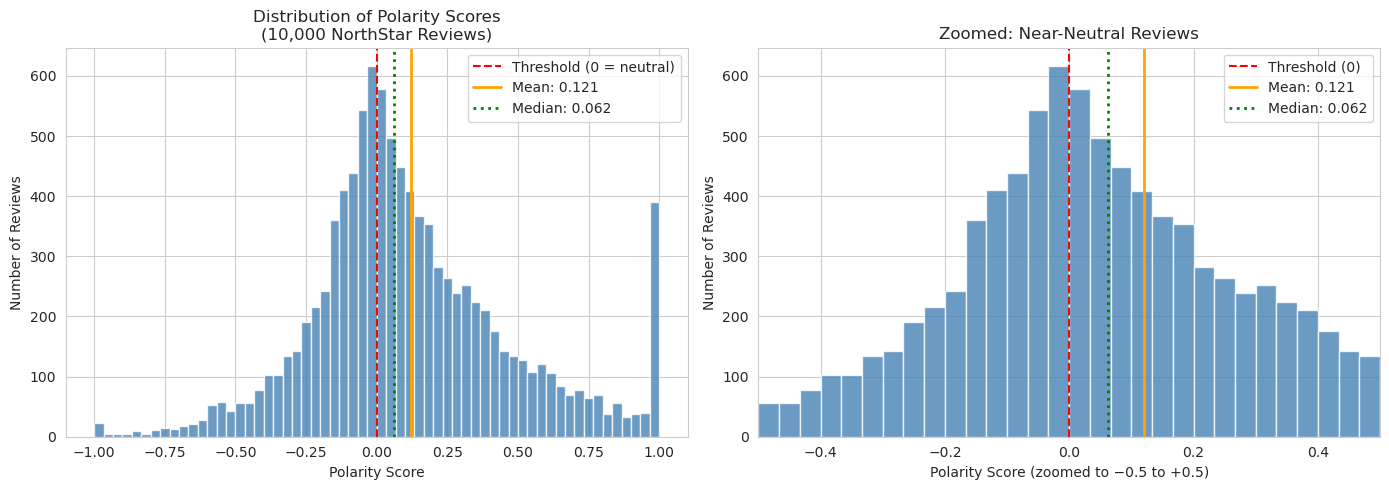


Mean polarity:   0.1206
Median polarity: 0.0618
Difference:      0.0588


In [3]:
# Plot the polarity score distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram of all polarity scores
ax1 = axes[0]
ax1.hist(polarity_scores, bins=60, color='steelblue', edgecolor='white', alpha=0.8)
ax1.axvline(x=0, color='red', linestyle='--', linewidth=1.5, label='Threshold (0 = neutral)')
ax1.axvline(x=polarity_scores.mean(), color='orange', linewidth=2, label=f'Mean: {polarity_scores.mean():.3f}')
ax1.axvline(x=np.median(polarity_scores), color='green', linewidth=2, linestyle=':', label=f'Median: {np.median(polarity_scores):.3f}')
ax1.set_xlabel('Polarity Score')
ax1.set_ylabel('Number of Reviews')
ax1.set_title("Distribution of Polarity Scores\n(10,000 NorthStar Reviews)")
ax1.legend()

# Zoomed view near the threshold
ax2 = axes[1]
ax2.hist(polarity_scores, bins=60, color='steelblue', edgecolor='white', alpha=0.8)
ax2.axvline(x=0, color='red', linestyle='--', linewidth=1.5, label='Threshold (0)')
ax2.axvline(x=polarity_scores.mean(), color='orange', linewidth=2, label=f'Mean: {polarity_scores.mean():.3f}')
ax2.axvline(x=np.median(polarity_scores), color='green', linewidth=2, linestyle=':', label=f'Median: {np.median(polarity_scores):.3f}')
ax2.set_xlim(-0.5, 0.5)
ax2.set_xlabel('Polarity Score (zoomed to −0.5 to +0.5)')
ax2.set_ylabel('Number of Reviews')
ax2.set_title('Zoomed: Near-Neutral Reviews')
ax2.legend()

plt.tight_layout()
plt.show()

print(f"\nMean polarity:   {polarity_scores.mean():.4f}")
print(f"Median polarity: {np.median(polarity_scores):.4f}")
print(f"Difference:      {polarity_scores.mean() - np.median(polarity_scores):.4f}")


### 💡 What do you notice?

- **The distribution is not a perfect bell curve** — it leans toward the positive side (*right-skewed*), with a long tail of moderately-high scores and a small spike at exactly +1.0 where the most enthusiastic reviews are clipped at the model's maximum value.
- **The mean and median disagree** — the mean (orange line) is pulled upward by the long tail of very positive reviews, while the median (green dotted line) sits lower at a more "typical" value. Together they tell a richer story than either one alone.
- **Many reviews cluster near zero** — scores between −0.2 and +0.2 are technically labelled POSITIVE or NEGATIVE, but they are only weakly so. A review with polarity 0.02 is not the same as one with polarity 0.95.

**Back to our scenario:**
> Sarah's "60% positive" comes from counting everything above zero. But many of those "positive" reviews have polarity scores barely above zero — they are more accurately described as "neutral." Priya is right to be sceptical of the exact number.

In [4]:
# Compare mean vs median: which should Sarah report?
mean_pol = polarity_scores.mean()
median_pol = np.median(polarity_scores)
std_pol = polarity_scores.std()

print("=== Summary Statistics ===")
print(f"  Mean polarity:    {mean_pol:.4f}")
print(f"  Median polarity:  {median_pol:.4f}")
print(f"  Std deviation:    {std_pol:.4f}")
print()
print(f"  Reviews with polarity > 0:    {(polarity_scores > 0).sum():,}  ({(polarity_scores > 0).mean():.1%})")
print(f"  Reviews with polarity > 0.1:  {(polarity_scores > 0.1).sum():,}  ({(polarity_scores > 0.1).mean():.1%})")
print(f"  Reviews with polarity > 0.3:  {(polarity_scores > 0.3).sum():,}  ({(polarity_scores > 0.3).mean():.1%})")
print()
print("Notice: the 'positive rate' changes dramatically depending on the threshold.")
print("Priya's question — 'is 60% really the right number?' — is even sharper than it sounds.")


=== Summary Statistics ===
  Mean polarity:    0.1206
  Median polarity:  0.0618
  Std deviation:    0.3564

  Reviews with polarity > 0:    6,000  (60.0%)
  Reviews with polarity > 0.1:  4,478  (44.8%)
  Reviews with polarity > 0.3:  2,562  (25.6%)

Notice: the 'positive rate' changes dramatically depending on the threshold.
Priya's question — 'is 60% really the right number?' — is even sharper than it sounds.


## Priya's Question — and Why It Matters

Sarah reported 60% positive. But notice:

- If Sarah had set the "positive" threshold at 0.1 instead of 0 — a slightly stricter definition — the rate would be different.
- If Sarah had analysed *next* week's reviews (a different sample), she might get 57% or 63% just from random variation.
- The mean polarity is a bit higher than the median — the distribution is not symmetric.

These aren't flaws in Sarah's analysis. They are **properties of working with sample data**. Every real dataset has them.

Priya's question in full:

> *"60%? Could it have been 50% if we just had a different week of reviews?*
> *And when you say 84% accuracy — is that the real accuracy, or just accuracy on your particular test set?"*

Sarah needs two things to answer Priya properly:

1. **Distributions** — to describe the shape and spread of the data, not just one number
2. **Confidence intervals** — to put a rigorous bracket around her estimates and explain how reliable they are

She'll also need to design an **A/B test** to find out whether the interventions Aisha is proposing actually work.

That's exactly what L02 teaches.

---
**Up next →** Open `pre-class.md` and work through the four-stage preparation guide (Stages 2–4 if you've already run this notebook).
Then in class: start with **`02_distributions.ipynb`**.
